# Samanburður á sentiment hjá DV, Vísi og RÚV

## Kafli 1 - Gemini

Hér eru Gemini-niðurstöður úr `gogn_labeled_master.csv`.

## Kafli 2 - IceBERT

Fyrir neðan kemur sami samanburður aftur, nema með IceBERT-niðurstöðum úr `icebert_labeled_master.csv`.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [9]:
base_path = Path('.')
labeled_path = base_path / 'gogn_labeled_master.csv'
gogn_path = base_path / 'gogn'

df = pd.read_csv(labeled_path, encoding='utf-8-sig')

sources = ['dv', 'visir', 'ruv']
sentiment_order = ['Positive', 'Neutral', 'Negative']
section_order = ['Innlent', 'Erlent', 'Sport', 'Annað']
colors = ['#2e8b57', '#9e9e9e', '#c0392b']

counts = (
    df[df['source'].isin(sources)]
    .groupby(['source', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=sources, columns=sentiment_order, fill_value=0)
)

counts

sentiment,Positive,Neutral,Negative
source,,,
dv,851,1808,2336
visir,1338,1589,2037
ruv,1151,1858,1961


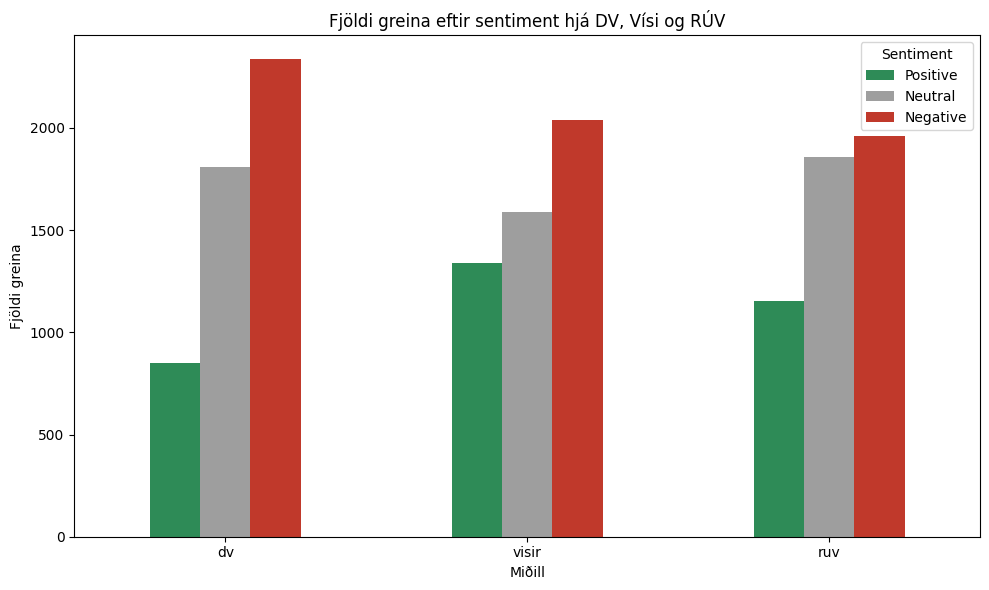

In [10]:
ax = counts.plot(
    kind='bar',
    figsize=(10, 6),
    color=colors
)

ax.set_title('Fjöldi greina eftir sentiment hjá DV, Vísi og RÚV')
ax.set_xlabel('Miðill')
ax.set_ylabel('Fjöldi greina')
ax.legend(title='Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
def load_visir_sections():
    visir = pd.read_csv(gogn_path / 'visir_gogn.csv', encoding='utf-8-sig')
    visir['source'] = 'visir'
    visir['source_section'] = 'Annað'
    visir.loc[visir['deild'].eq('Sport'), 'source_section'] = 'Sport'
    visir.loc[
        visir['deild'].eq('Fréttir') & visir['flokkur'].eq('Innlent'),
        'source_section'
    ] = 'Innlent'
    visir.loc[
        visir['deild'].eq('Fréttir') & visir['flokkur'].eq('Erlent'),
        'source_section'
    ] = 'Erlent'
    return visir[['source', 'fyrirsogn', 'source_section']].drop_duplicates()


def load_ruv_sections():
    ruv = pd.read_csv(gogn_path / 'ruv_gogn.csv', encoding='utf-8-sig')
    ruv['source'] = 'ruv'
    ruv['source_section'] = 'Annað'
    ruv.loc[ruv['deild'].eq('Innlendar fréttir'), 'source_section'] = 'Innlent'
    ruv.loc[ruv['deild'].eq('Erlendar fréttir'), 'source_section'] = 'Erlent'
    ruv.loc[ruv['deild'].eq('Íþróttir'), 'source_section'] = 'Sport'
    return ruv[['source', 'fyrirsogn', 'source_section']].drop_duplicates()


def load_dv_sections():
    dv = pd.read_csv(gogn_path / 'dv_gogn.csv', encoding='utf-8-sig')
    dv['source'] = 'dv'

    flokkur = dv['flokkur'].fillna('')
    flokkar = dv['flokkar'].fillna('')
    seg = dv['slod'].fillna('').astype(str).str.split('/').str[3].fillna('')

    dv['source_section'] = 'Annað'
    dv.loc[
        seg.isin(['433', 'sport'])
        | flokkar.str.contains('Sport', regex=False)
        | flokkur.isin(['433', 'Sport']),
        'source_section'
    ] = 'Sport'
    dv.loc[
        (dv['source_section'] == 'Annað')
        & (
            seg.eq('pressan')
            | flokkar.str.contains('Erlent', regex=False)
            | flokkur.eq('Erlent')
        ),
        'source_section'
    ] = 'Erlent'
    dv.loc[
        (dv['source_section'] == 'Annað')
        & (seg.eq('frettir') | flokkar.str.contains('Innlent', regex=False)),
        'source_section'
    ] = 'Innlent'

    return dv[['source', 'fyrirsogn', 'source_section']].drop_duplicates()


source_details = pd.concat(
    [
        load_dv_sections(),
        load_visir_sections(),
        load_ruv_sections(),
    ],
    ignore_index=True,
)

source_details = source_details.drop_duplicates(subset=['source', 'fyrirsogn'])

merged = df.merge(source_details, on=['source', 'fyrirsogn'], how='left')
merged['source_section'] = merged['source_section'].fillna('Annað')

section_counts = (
    merged.groupby(['source', 'source_section'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=sources, columns=section_order, fill_value=0)
)

section_counts


source_section,Innlent,Erlent,Sport,Annað
source,,,,
dv,1324,749,2208,714
visir,1839,558,2475,92
ruv,2521,1328,667,454


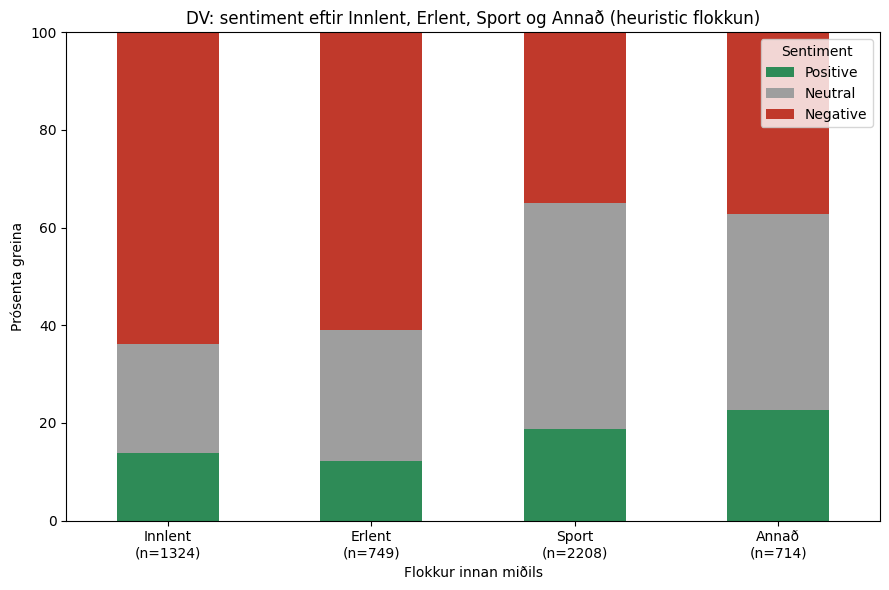

sentiment,Positive,Neutral,Negative
source_section,,,
Innlent,13.897281,22.356495,63.746224
Erlent,12.283044,26.835781,60.881175
Sport,18.750000,46.376812,34.873188
Annað,22.549020,40.196078,37.254902


In [12]:
def plot_source_section_percentages(merged_df, source_name, title):
    plot_df = (
        merged_df[merged_df['source'].eq(source_name)]
        .groupby(['source_section', 'sentiment'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=section_order, columns=sentiment_order, fill_value=0)
    )

    section_sizes = plot_df.sum(axis=1)
    plot_pct = plot_df.div(section_sizes.replace(0, 1), axis=0) * 100
    labels = [f'{section}\n(n={int(section_sizes.loc[section])})' for section in plot_pct.index]

    ax = plot_pct.plot(
        kind='bar',
        stacked=True,
        figsize=(9, 6),
        color=colors
    )

    ax.set_title(title)
    ax.set_xlabel('Flokkur innan miðils')
    ax.set_ylabel('Prósenta greina')
    ax.set_ylim(0, 100)
    ax.set_xticklabels(labels, rotation=0)
    ax.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()

    return plot_pct


dv_percentages = plot_source_section_percentages(
    merged,
    'dv',
    'DV: sentiment eftir Innlent, Erlent, Sport og Annað (heuristic flokkun)'
)

dv_percentages

In [13]:
dv_hreinsad = pd.read_csv(gogn_path / 'dv_hreinsad.csv', encoding='utf-8-sig')
dv_hreinsad = dv_hreinsad[['fyrirsogn', 'hreinsad_flokkun']].drop_duplicates()

dv_labeled = df[df['source'].eq('dv')].merge(dv_hreinsad, on='fyrirsogn', how='left')
dv_labeled['hreinsad_flokkun'] = dv_labeled['hreinsad_flokkun'].fillna('Annað')

dv_hreinsad_counts = (
    dv_labeled['hreinsad_flokkun']
    .value_counts()
    .reindex(section_order, fill_value=0)
)

dv_hreinsad_counts

hreinsad_flokkun
Innlent    1207
Erlent      616
Sport      2216
Annað       956
Name: count, dtype: int64

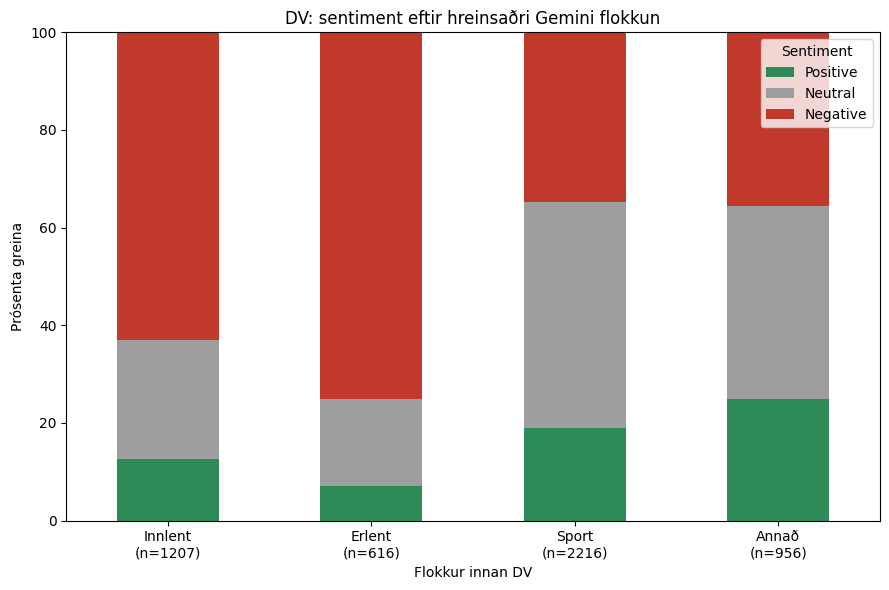

sentiment,Positive,Neutral,Negative
hreinsad_flokkun,,,
Innlent,12.510356,24.440762,63.048882
Erlent,6.980519,17.857143,75.162338
Sport,18.953069,46.209386,34.837545
Annað,24.790795,39.644351,35.564854


In [14]:
dv_hreinsad_plot_df = (
    dv_labeled.groupby(['hreinsad_flokkun', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=section_order, columns=sentiment_order, fill_value=0)
)

dv_hreinsad_sizes = dv_hreinsad_plot_df.sum(axis=1)
dv_hreinsad_pct = dv_hreinsad_plot_df.div(dv_hreinsad_sizes.replace(0, 1), axis=0) * 100
dv_hreinsad_labels = [f'{section}\n(n={int(dv_hreinsad_sizes.loc[section])})' for section in dv_hreinsad_pct.index]

ax = dv_hreinsad_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    color=colors
)

ax.set_title('DV: sentiment eftir hreinsaðri Gemini flokkun')
ax.set_xlabel('Flokkur innan DV')
ax.set_ylabel('Prósenta greina')
ax.set_ylim(0, 100)
ax.set_xticklabels(dv_hreinsad_labels, rotation=0)
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

dv_hreinsad_pct

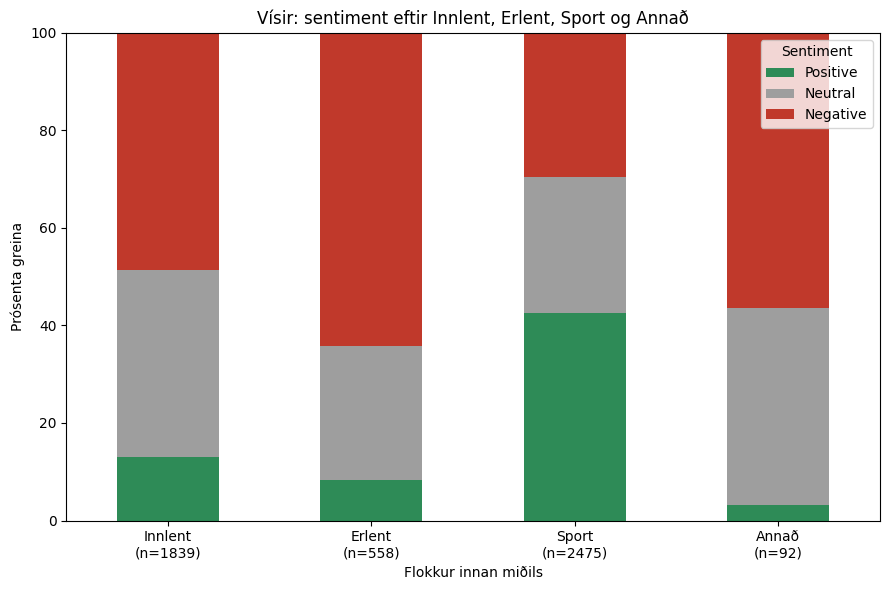

sentiment,Positive,Neutral,Negative
source_section,,,
Innlent,12.941816,38.390430,48.667754
Erlent,8.243728,27.598566,64.157706
Sport,42.464646,27.959596,29.575758
Annað,3.260870,40.217391,56.521739


In [15]:
visir_percentages = plot_source_section_percentages(
    merged,
    'visir',
    'Vísir: sentiment eftir Innlent, Erlent, Sport og Annað'
)

visir_percentages

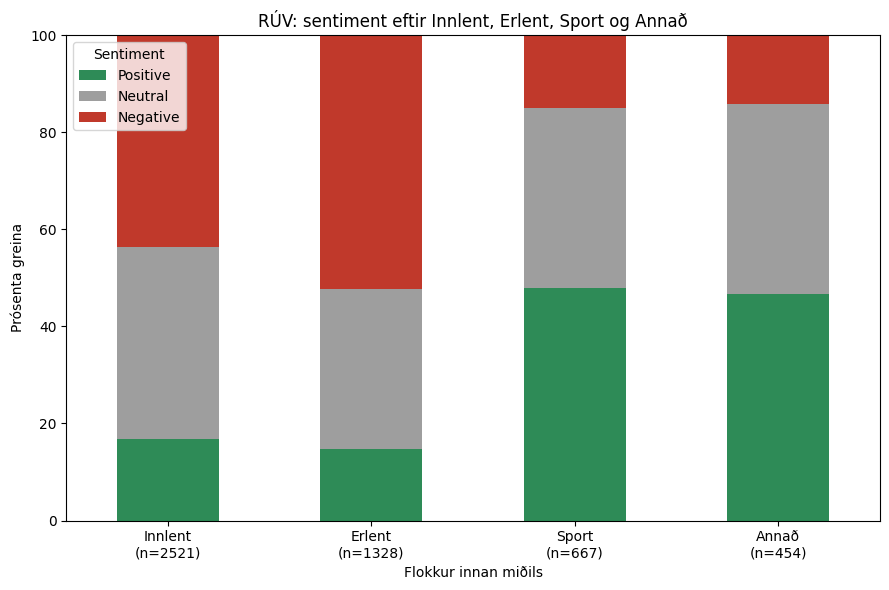

sentiment,Positive,Neutral,Negative
source_section,,,
Innlent,16.779056,39.508132,43.712812
Erlent,14.759036,32.906627,52.334337
Sport,47.976012,37.031484,14.992504
Annað,46.696035,39.207048,14.096916


In [16]:
ruv_percentages = plot_source_section_percentages(
    merged,
    'ruv',
    'RÚV: sentiment eftir Innlent, Erlent, Sport og Annað'
)

ruv_percentages

## Kafli 2 - IceBERT

Hér kemur sami samanburður og fyrir Gemini, nema nú með niðurstöðum úr `icebert_labeled_master.csv`.
Í þessum gögnum eru `1000` fyrirsagnir frá hverjum miðli.


In [ ]:
icebert_labeled_path = base_path / 'icebert_labeled_master.csv'
icebert_df = pd.read_csv(icebert_labeled_path, encoding='utf-8-sig')
icebert_df = icebert_df[['source', 'fyrirsogn', 'sentiment']].copy()
icebert_df['source'] = icebert_df['source'].astype(str).str.strip().str.lower()
icebert_df['fyrirsogn'] = icebert_df['fyrirsogn'].astype(str).str.strip()
icebert_df['sentiment'] = icebert_df['sentiment'].astype(str).str.strip()
icebert_df = icebert_df[icebert_df['source'].isin(sources)].drop_duplicates()

icebert_counts = (
    icebert_df.groupby(['source', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=sources, columns=sentiment_order, fill_value=0)
)

icebert_counts


In [ ]:
ax = icebert_counts.plot(
    kind='bar',
    figsize=(10, 6),
    color=colors
)

ax.set_title('Fjöldi greina eftir sentiment hjá DV, Vísi og RÚV - IceBERT')
ax.set_xlabel('Miðill')
ax.set_ylabel('Fjöldi greina')
ax.legend(title='Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
icebert_source_details = pd.concat(
    [
        load_dv_sections(),
        load_visir_sections(),
        load_ruv_sections(),
    ],
    ignore_index=True,
)

icebert_source_details = icebert_source_details.drop_duplicates(subset=['source', 'fyrirsogn'])

icebert_merged = icebert_df.merge(icebert_source_details, on=['source', 'fyrirsogn'], how='left')
icebert_merged['source_section'] = icebert_merged['source_section'].fillna('Annað')

icebert_section_counts = (
    icebert_merged.groupby(['source', 'source_section'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=sources, columns=section_order, fill_value=0)
)

icebert_section_counts


In [ ]:
icebert_dv_percentages = plot_source_section_percentages(
    icebert_merged,
    'dv',
    'DV: sentiment eftir Innlent, Erlent, Sport og Annað (heuristic flokkun, IceBERT)'
)

icebert_dv_percentages


In [ ]:
icebert_dv_hreinsad = pd.read_csv(gogn_path / 'dv_hreinsad.csv', encoding='utf-8-sig')
icebert_dv_hreinsad = icebert_dv_hreinsad[['fyrirsogn', 'hreinsad_flokkun']].drop_duplicates()

icebert_dv_labeled = icebert_df[icebert_df['source'].eq('dv')].merge(icebert_dv_hreinsad, on='fyrirsogn', how='left')
icebert_dv_labeled['hreinsad_flokkun'] = icebert_dv_labeled['hreinsad_flokkun'].fillna('Annað')

icebert_dv_hreinsad_counts = (
    icebert_dv_labeled['hreinsad_flokkun']
    .value_counts()
    .reindex(section_order, fill_value=0)
)

icebert_dv_hreinsad_counts

icebert_dv_hreinsad_plot_df = (
    icebert_dv_labeled.groupby(['hreinsad_flokkun', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=section_order, columns=sentiment_order, fill_value=0)
)

icebert_dv_hreinsad_sizes = icebert_dv_hreinsad_plot_df.sum(axis=1)
icebert_dv_hreinsad_pct = icebert_dv_hreinsad_plot_df.div(icebert_dv_hreinsad_sizes.replace(0, 1), axis=0) * 100
icebert_dv_hreinsad_labels = [f'{section}\n(n={int(icebert_dv_hreinsad_sizes.loc[section])})' for section in icebert_dv_hreinsad_pct.index]

ax = icebert_dv_hreinsad_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6),
    color=colors
)

ax.set_title('DV: sentiment eftir hreinsaðri DV flokkun - IceBERT')
ax.set_xlabel('Flokkur innan DV')
ax.set_ylabel('Prósenta greina')
ax.set_ylim(0, 100)
ax.set_xticklabels(icebert_dv_hreinsad_labels, rotation=0)
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

icebert_dv_hreinsad_pct


In [ ]:
icebert_visir_percentages = plot_source_section_percentages(
    icebert_merged,
    'visir',
    'Vísir: sentiment eftir Innlent, Erlent, Sport og Annað - IceBERT'
)

icebert_visir_percentages


In [ ]:
icebert_ruv_percentages = plot_source_section_percentages(
    icebert_merged,
    'ruv',
    'RÚV: sentiment eftir Innlent, Erlent, Sport og Annað - IceBERT'
)

icebert_ruv_percentages
